<a href="https://colab.research.google.com/github/eunyeongkimm/ada_deeplearning/blob/main/ADA_betaVAE_latentsampling_interpolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 심화과제 3-4

## beta-VAE 모델 구축(+튜닝) 및 학습

In [9]:
import tensorflow as tf
import keras
from keras import layers, datasets, models, utils
from keras import backend as K
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import imageio
import io, os, base64
from IPython.display import Image, display, HTML
from sklearn.decomposition import PCA

# ── 재현성 ──────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

# ── 하이퍼파라미터 (튜닝 포인트) ─────────
# 1. beta: 1 → 4  (disentanglement 강화, class 분리도 향상)
# 2. latent_dim: 3(3D시각화를 위해 기존 유지)
# 3.  intermediate_dim: 16 → 64 (표현력 향상)
# 4.  learning_rate: default(1e-3) → 3e-4 (beta 상승에 따른 안정적 수렴)
# 5.  epochs: 30 → 50 (충분한 수렴 보장)
BETA            = 4      # (원본: 1)
LATENT_DIM = 3
INTERMEDIATE_DIM = 64     # (원본: 16)
BATCH_SIZE      = 128
EPOCHS          = 50      # (원본: 30)
LEARNING_RATE   = 3e-4    # (원본: default Adam)

# 시각화용 색상 팔레트 (0~9 숫자)
CMAP = plt.get_cmap('tab10')

print(f"TensorFlow: {tf.__version__}  |  Keras: {keras.__version__}")
print(f"BETA={BETA}, LATENT_DIM={LATENT_DIM}, INTERMEDIATE_DIM={INTERMEDIATE_DIM}")
print(f"LEARNING_RATE={LEARNING_RATE}, EPOCHS={EPOCHS}, BATCH_SIZE={BATCH_SIZE}")


TensorFlow: 2.19.0  |  Keras: 3.13.2
BETA=4, LATENT_DIM=3, INTERMEDIATE_DIM=64
LEARNING_RATE=0.0003, EPOCHS=50, BATCH_SIZE=128


In [10]:
# 3.2.2와 달리, label을 보존하여 가져온다
# ★ TUNED ★  label 보존 (원본: (x_train, _), (x_test, _))
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

mnist_digits = np.concatenate([x_train, x_test], axis=0)
mnist_labels = np.concatenate([y_train, y_test], axis=0)   # ★ label 추가

# normalize + channel dim
mnist_digits = mnist_digits[..., tf.newaxis].astype("float32") / 255.0

print(f"mnist_digits shape : {mnist_digits.shape}")
print(f"mnist_labels shape : {mnist_labels.shape}")
print(f"classes            : {np.unique(mnist_labels)}")

mnist_digits shape : (70000, 28, 28, 1)
mnist_labels shape : (70000,)
classes            : [0 1 2 3 4 5 6 7 8 9]


### 모델 정의

- 원본 모델 구조 (변경 없는 부분)
| 구성요소 | 원본 |
|---|---|
| Sampling layer | Reparameterization trick (동일) |
| Encoder Conv | Conv2D×3 (128→64→64) + Flatten + Dense (동일) |
| Decoder | Dense + Reshape + Conv2DTranspose×3 (동일) |
| Loss | Reconstruction + β·KL (동일) |

- 튜닝 포인트
| 튜닝 항목 | 원본 | 변경 후 | 이유 |
|---|---|---|---|
| beta | 1 | 4 | KL 페널티 강화 → class 분리도 향상 |
| intermediate_dim | 16 | 64 | z_mean/z_log_var 표현력 향상 |
| learning_rate | 1e-3 (default) | **3e-4** | beta 상승에 따른 안정적 수렴 |
| epochs | 30 | **50** | 충분한 수렴 보장 |
| label 활용 | ✗ | **✓** | 시각화·interpolation에 필요 |

In [11]:
# ─────────────────────────────────────
#  Sampling Layer  (원본과 동일)
# ─────────────────────────────────────
class Sampling(layers.Layer):
    """z_mean, z_log_var → z  (Reparameterization trick)"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim   = tf.shape(z_mean)[1]
        eps   = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * eps


# ─────────────────────────────────────
#  Encoder  q_φ(·)  (intermediate_dim 튜닝)
# ─────────────────────────────────────
encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64,  3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2D(64,  3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(INTERMEDIATE_DIM, activation="relu")(x)   # ★ 32 (원본: 16)
z_mean    = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z         = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()


# ─────────────────────────────────────
#  Decoder  p_θ(·)  (원본과 동일)
# ─────────────────────────────────────
latent_inputs = keras.Input(shape=(LATENT_DIM,))
x = layers.Dense(4 * 4 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((4, 4, 64))(x)
x = layers.Conv2DTranspose(64,  3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(64,  3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
# 32x32 → crop to 28x28
x = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder_outputs = layers.Cropping2D(cropping=((2, 2), (2, 2)))(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()


# ─────────────────────────────────────
#  Beta-VAE  (beta 튜닝)
# ─────────────────────────────────────
class BetaVAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta    = beta          # ★ beta=4 (원본: 1)
        self.total_loss_tracker         = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker            = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker,
                self.reconstruction_loss_tracker,
                self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            # pixel-wise binary crossentropy
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )
            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                              axis=1)
            )
            total_loss = recon_loss + self.beta * kl_loss   # ★ beta 적용

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


vae = BetaVAE(encoder, decoder, beta=BETA)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │      1,280 │ input_layer_2[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 7, 7, 64)  │     73,792 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 4, 4, 64)  │     36,928 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1024)      │          0 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     65,600 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 3)         │        195 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 3)         │        195 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 3)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 177,990 (695.27 KB)

 Trainable params: 177,990 (695.27 KB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 8, 8, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 16, 16, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 32, 32, 128)    │        73,856 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 32, 32, 1)      │         1,153 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d_1 (Cropping2D)       │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,961 (597.50 KB)

 Trainable params: 152,961 (597.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - kl_loss: 1.5738 - reconstruction_loss: 215.2759 - total_loss: 221.5711
Epoch 2/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 4.3427 - reconstruction_loss: 150.9933 - total_loss: 168.3642
Epoch 3/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 4.8337 - reconstruction_loss: 143.5379 - total_loss: 162.8727
Epoch 4/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 5.0336 - reconstruction_loss: 140.6133 - total_loss: 160.7477
Epoch 5/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 5.1611 - reconstruction_loss: 138.8110 - total_loss: 159.4555
Epoch 6/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 5.2472 - reconstruction_loss: 137.5282 - total_loss: 158.5169
Epoch 7/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 5.3129 - reconstruction_loss: 136.5421 - total_loss: 157.7938
Epoch 8/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 5.3651 - reconstruction_loss: 135.8060 - total_loss: 157.266

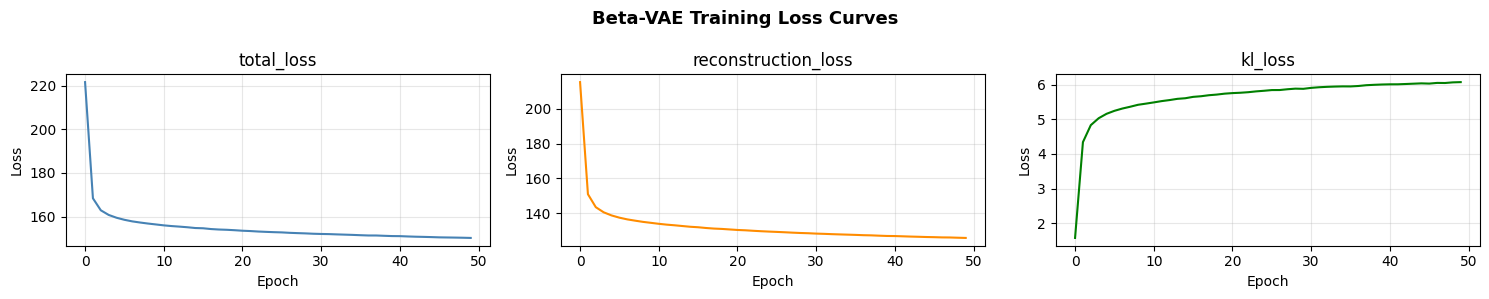

학습 완료


In [12]:
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))  # ★ lr=5e-4

history = vae.fit(
    mnist_digits,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# ── 손실 곡선 ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, key, color in zip(axes,
                           ['total_loss', 'reconstruction_loss', 'kl_loss'],
                           ['steelblue', 'darkorange', 'green']):
    ax.plot(history.history[key], color=color)
    ax.set_title(key)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
plt.suptitle("Beta-VAE Training Loss Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("학습 완료")

## Q1. Encoder가 만들어 내는 분포에서 하나의 sample에서 10번씩 sampling 하여 Latent space에 mapping되는 point가 늘어나는 것을 시각화 해 보자. 2D, 3D에서 각각 시각화 하자.

- 관찰 결과:
  - 별(★)은 z_mean을 나타내며, 주변 점(·)은 동일한 분포에서 10번 샘플링된 z
  - 클래스 1, 6은 명확히 분리되는 반면, 나머지 클래스는 latent_dim=3으로, 10개 클래스를 표현하는 구조적 한계로 인해 중앙에 밀집
  - β=4는 disentanglement와 reconstruction 품질 사이의 균형을 유지

z_sampled shape : (5000, 3)
labels_rep shape: (5000,)


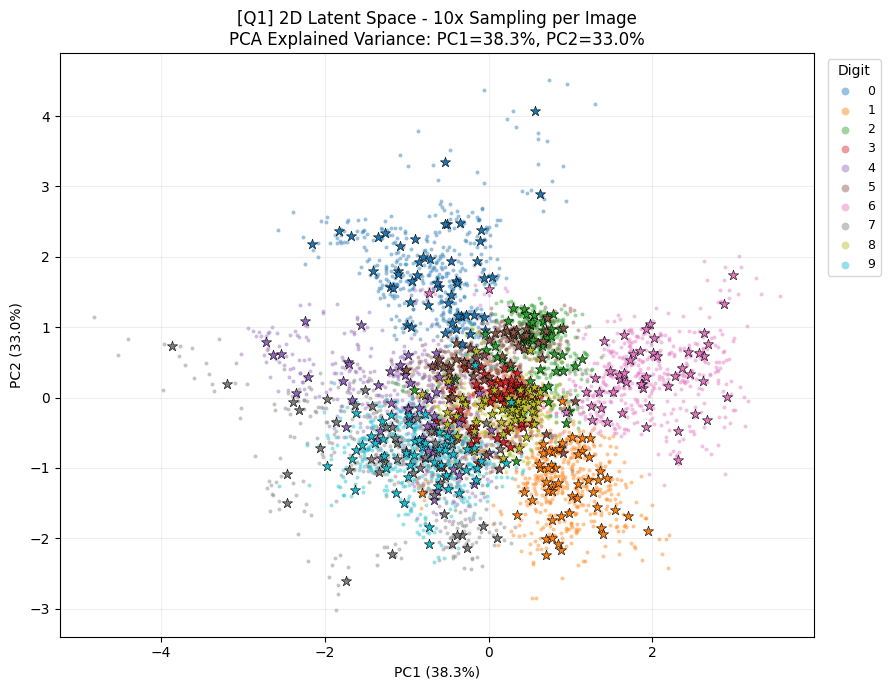

★ star(★): z_mean (center of distribution)  /  dot: 10x resampled z


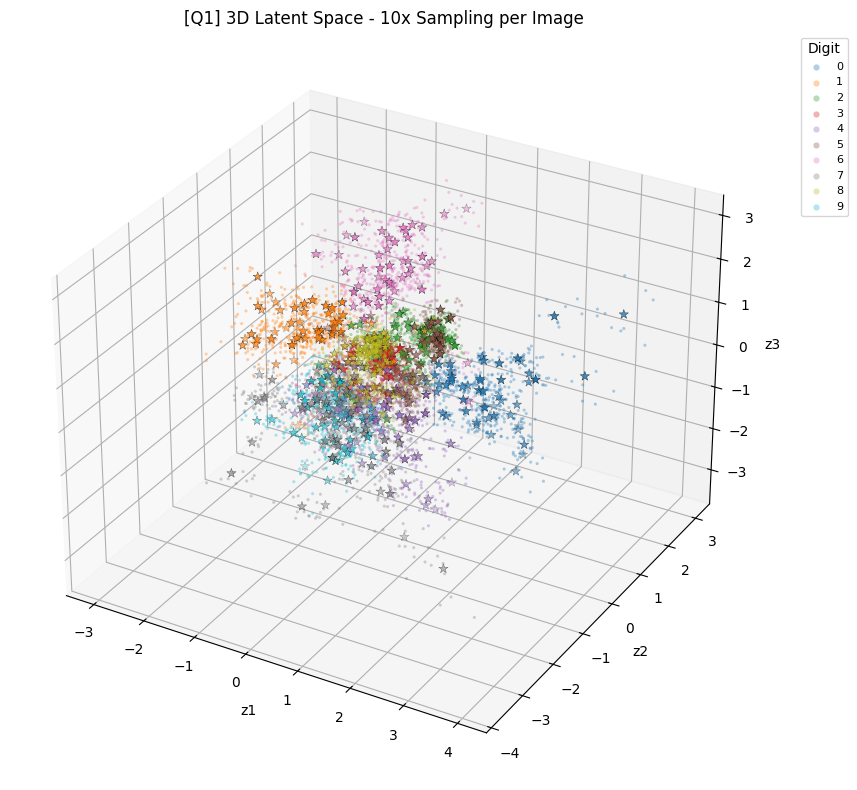

star(★): z_mean (center of distribution)  /  dot: 10x resampled z


In [14]:
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

# ── 시각화에 사용할 샘플 수 ─────────────────────
N_SAMPLES   = 500
N_REPEAT    = 10

# ── 클래스별 대표 이미지 추출 ────────────────────
sample_images = []
sample_labels = []
for cls in range(10):
    idx = np.where(mnist_labels == cls)[0][:N_SAMPLES // 10]
    sample_images.append(mnist_digits[idx])
    sample_labels.extend([cls] * len(idx))

sample_images = np.concatenate(sample_images, axis=0)
sample_labels = np.array(sample_labels)

# ── Encoder → z_mean, z_log_var 추출 ─────────────
z_mean_all, z_log_var_all, _ = encoder.predict(sample_images, batch_size=256, verbose=0)

# ── 각 이미지에서 10번씩 재샘플링 ───────────────────
z_sampled_list = []
label_repeated  = []

for i in range(len(sample_images)):
    zm  = z_mean_all[i]
    zlv = z_log_var_all[i]
    std = np.exp(0.5 * zlv)
    eps = np.random.randn(N_REPEAT, LATENT_DIM)
    z_s = zm[np.newaxis, :] + std[np.newaxis, :] * eps
    z_sampled_list.append(z_s)
    label_repeated.extend([sample_labels[i]] * N_REPEAT)

z_sampled  = np.concatenate(z_sampled_list, axis=0)
labels_rep = np.array(label_repeated)

print(f"z_sampled shape : {z_sampled.shape}")
print(f"labels_rep shape: {labels_rep.shape}")


# ═══════════════════════════════════════════
#  2D 시각화 (PCA 2D 투영)
# ═══════════════════════════════════════════
pca     = PCA(n_components=2)
z_2d    = pca.fit_transform(z_sampled)
var_ratio = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 7))
for cls in range(10):
    mask = labels_rep == cls
    ax.scatter(z_2d[mask, 0], z_2d[mask, 1],
               c=[CMAP(cls)], label=str(cls), s=8, alpha=0.45, linewidths=0)

z_mean_2d = pca.transform(z_mean_all)
for cls in range(10):
    mask = sample_labels == cls
    ax.scatter(z_mean_2d[mask, 0], z_mean_2d[mask, 1],
               c=[CMAP(cls)], marker='*', s=60,
               edgecolors='black', linewidths=0.4, zorder=5)

ax.set_title(f"[Q1] 2D Latent Space - 10x Sampling per Image\n"
             f"PCA Explained Variance: PC1={var_ratio[0]:.1%}, PC2={var_ratio[1]:.1%}",
             fontsize=12)
ax.set_xlabel(f"PC1 ({var_ratio[0]:.1%})")
ax.set_ylabel(f"PC2 ({var_ratio[1]:.1%})")
ax.legend(title="Digit", bbox_to_anchor=(1.01, 1), loc='upper left',
          markerscale=2, fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
print("★ star(★): z_mean (center of distribution)  /  dot: 10x resampled z")


# ═══════════════════════════════════════════
#  3D 시각화
# ═══════════════════════════════════════════

fig = plt.figure(figsize=(11, 8))
ax3 = fig.add_subplot(111, projection='3d')

for cls in range(10):
    mask = labels_rep == cls
    ax3.scatter(z_sampled[mask, 0], z_sampled[mask, 1], z_sampled[mask, 2],
                c=[CMAP(cls)], label=str(cls), s=5, alpha=0.35, linewidths=0)

# z_mean 별 표시
for cls in range(10):
    mask = sample_labels == cls
    ax3.scatter(z_mean_all[mask, 0], z_mean_all[mask, 1], z_mean_all[mask, 2],
                c=[CMAP(cls)], marker='*', s=50,
                edgecolors='black', linewidths=0.3, zorder=5)

ax3.set_title("[Q1] 3D Latent Space - 10x Sampling per Image", fontsize=12)
ax3.set_xlabel("z1")
ax3.set_ylabel("z2")
ax3.set_zlabel("z3")
ax3.legend(title="Digit", bbox_to_anchor=(1.05, 1), loc='upper left',
           markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()
print("star(★): z_mean (center of distribution)  /  dot: 10x resampled z")

In [15]:
# plotly version
import plotly.express as px
import pandas as pd

df = pd.DataFrame(z_sampled, columns=['z1','z2','z3'])
df['digit'] = labels_rep.astype(str)

fig = px.scatter_3d(df, x='z1', y='z2', z='z3',
                    color='digit', opacity=0.4,
                    title='[Q1] 3D Latent Space - 10x Sampling',
                    width=800, height=700)
fig.update_traces(marker_size=2)
fig.show()

##  Q2.몇 개 class의 중앙을 잇는 interpolation으로 생성된 image를 동영상으로 만들어 보자.



- 아이디어
  - 각 class의 Latent Centroid(z_mean 평균) 를 구한 뒤,
  인접한 두 centroid 사이를 Linear Interpolation 하여 z 벡터 시퀀스를 생성
  - 각 z를 Decoder에 통과시켜 이미지를 생성하고, 순서대로 이어 붙여 GIF로 재생
  - Latent space가 연속적이고 의미있게 구성되어 있다면,
  숫자가 자연스럽게 변형되며 전환되는 것을 확인할 수 있음

- 보간 순서
  
  - 0 → 6 → 8 → 3 → 9 → 4 → 7 → 1 → 0 (순환, 모양이 유사한 class끼리 연결)

- 관찰 결과
  - GIF에서 숫자가 한 class에서 다음 class로 점진적으로 변형되는 것을 확인
  - 3D 그래프의 빨간 선이 각 centroid(◆)를 연결하는 보간 경로를 나타냄
  - Latent space가 단순 압축이 아닌 의미 있는 구조를 학습했음을 시사
  - 중간에 보간 클래스로 선택하지 않은 숫자(2 등)가 등장하는 것은 오류가 아니라, 보간 대상 class의 centroid 사이 공간이 선택하지 않은 숫자의 centroid 근처를 지나기 때문 → Latent space가 시각적 유사성을 반영한 구조임을 시사

Encoding all images to compute centroids...
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  class 0 centroid: [ 1.63   0.68  -0.143]
  class 1 centroid: [-1.329 -0.462  0.894]
  class 2 centroid: [-0.055  1.176 -0.061]
  class 3 centroid: [-0.471  0.418 -0.326]
  class 4 centroid: [ 0.333 -0.676 -0.705]
  class 5 centroid: [0.569 0.065 0.047]
  class 6 centroid: [-0.338  1.262  1.341]
  class 7 centroid: [-0.132 -1.703 -0.385]
  class 8 centroid: [-0.175 -0.071 -0.048]
  class 9 centroid: [-0.104 -0.826 -0.707]

Total interpolation frames: 240


/tmp/ipykernel_16186/2080850678.py:56: DeprecationWarning:

Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.




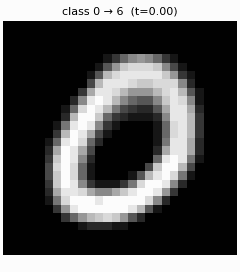

In [18]:
# ── 설정 ─────────────────────────────────────
INTERP_CLASSES = [0, 6, 8, 3, 9, 4, 7, 1]  # 모양 유사한 것끼리
N_STEPS         = 30
GIF_FPS         = 15

# ── 전체 데이터에서 class별 centroid 계산 ─────────
print("Encoding all images to compute centroids...")
z_mean_full, _, _ = encoder.predict(mnist_digits, batch_size=512, verbose=1)

centroids = {}
for cls in range(10):
    mask = mnist_labels == cls
    centroids[cls] = z_mean_full[mask].mean(axis=0)
    print(f"  class {cls} centroid: {centroids[cls].round(3)}")

# ── 보간 시퀀스 생성 ──────────────────────────────
def lerp(z_a, z_b, n_steps):
    t = np.linspace(0, 1, n_steps)
    return np.stack([z_a * (1 - ti) + z_b * ti for ti in t])

all_z = []
segment_labels = []
cycle = INTERP_CLASSES + [INTERP_CLASSES[0]]

for i in range(len(cycle) - 1):
    c_start = cycle[i]
    c_end   = cycle[i + 1]
    all_z.append(lerp(centroids[c_start], centroids[c_end], N_STEPS))
    segment_labels.append((c_start, c_end))

all_z = np.concatenate(all_z, axis=0)
print(f"\nTotal interpolation frames: {len(all_z)}")

# ── Decoder로 이미지 생성 ─────────────────────────
gen_images = decoder.predict(all_z, batch_size=128, verbose=0)

# ── 메모리에서 GIF 생성 (파일 저장 없이) ────────────
frames = []
for frame_idx in range(len(gen_images)):
    img = gen_images[frame_idx, :, :, 0]
    seg_idx    = frame_idx // N_STEPS
    local_step = frame_idx %  N_STEPS
    c_s, c_e   = segment_labels[seg_idx]
    t_ratio    = local_step / (N_STEPS - 1)

    fig, ax = plt.subplots(figsize=(3, 3.4))
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"class {c_s} → {c_e}  (t={t_ratio:.2f})", fontsize=10)
    ax.axis('off')
    plt.tight_layout(pad=0.3)

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=80)
    plt.close(fig)
    buf.seek(0)
    frames.append(imageio.imread(buf))

# ── 메모리에서 바로 인라인 재생 ──────────────────────
gif_buf = io.BytesIO()
imageio.mimsave(gif_buf, frames, format='gif', fps=GIF_FPS, loop=0)
gif_buf.seek(0)
gif_b64 = base64.b64encode(gif_buf.read()).decode("utf-8")

html_str = (
    f'<h3>🎬 Interpolation GIF (class {INTERP_CLASSES[0]}→'
    + '→'.join(str(c) for c in INTERP_CLASSES[1:])
    + f'→{INTERP_CLASSES[0]})</h3>'
    f'<img src="data:image/gif;base64,{gif_b64}" '
    f'style="width:280px; border:1px solid #ccc; border-radius:6px;"/>'
)
display(HTML(html_str))


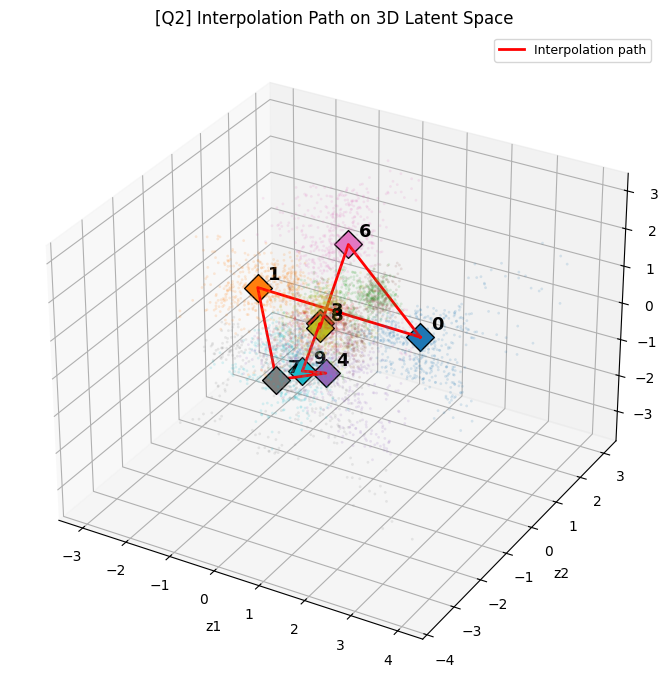

In [19]:

# ── 보간 경로를 3D Latent Space 위에 표시 ──────────
fig = plt.figure(figsize=(10, 7))
ax3 = fig.add_subplot(111, projection='3d')

for cls in range(10):
    mask = labels_rep == cls
    ax3.scatter(z_sampled[mask, 0], z_sampled[mask, 1], z_sampled[mask, 2],
                c=[CMAP(cls)], s=4, alpha=0.15, linewidths=0)

ax3.plot(all_z[:, 0], all_z[:, 1], all_z[:, 2],
         color='red', linewidth=2, zorder=10, label='Interpolation path')

for cls in INTERP_CLASSES:
    c = centroids[cls]
    ax3.scatter(*c, color=CMAP(cls), s=200, marker='D',
                edgecolors='black', linewidths=1, zorder=11)
    ax3.text(c[0]+0.15, c[1]+0.15, c[2]+0.15,   # offset 추가
             f"{cls}", fontsize=13, fontweight='bold',
             color='black', zorder=12)

ax3.set_title("[Q2] Interpolation Path on 3D Latent Space", fontsize=12)
ax3.set_xlabel("z1"); ax3.set_ylabel("z2"); ax3.set_zlabel("z3")
ax3.legend(fontsize=9)
plt.tight_layout()
plt.show()